In [1]:
import numpy as np
import pandas as pd
import  matplotlib.pyplot as plt 

In [2]:
data = {
    "Salary": [20000, 25000, 27000, 30000, 32000, 35000, 40000, 1000000]  #  added outlier
}

df = pd.DataFrame(data)
print(df)

    Salary
0    20000
1    25000
2    27000
3    30000
4    32000
5    35000
6    40000
7  1000000


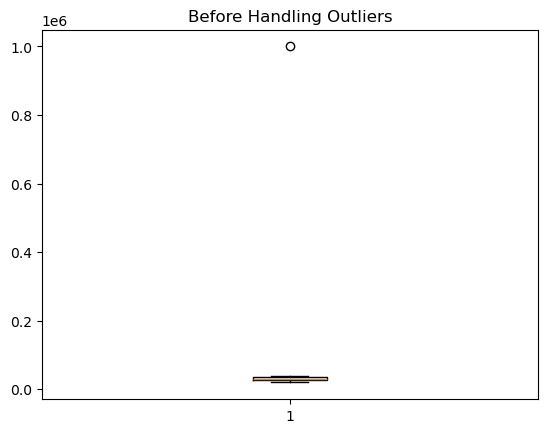

In [8]:
# visualizing with Boxplot
plt.boxplot(df["Salary"])
plt.title("Before Handling Outliers")
plt.show()


In [7]:
#Deceting  the outliers with IQR

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower:", lower_bound)
print("Upper:", upper_bound)

Lower: 11875.0
Upper: 50875.0


In [10]:
#Identifying the outliers 
outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
print(outliers)

    Salary
7  1000000


In [11]:
# Remove Outliers
df_removed = df[(df["Salary"] >= lower_bound) & (df["Salary"] <= upper_bound)]
print(df_removed)

   Salary
0   20000
1   25000
2   27000
3   30000
4   32000
5   35000
6   40000


In [14]:
#Replace with Median
median = df["Salary"].median()

df_replaced = df.copy()
df_replaced.loc[(df_replaced["Salary"] < lower_bound) | 
                (df_replaced["Salary"] > upper_bound), "Salary"] = median

print(df_replaced)

   Salary
0   20000
1   25000
2   27000
3   30000
4   32000
5   35000
6   40000
7   31000


In [15]:
#Capping (Winsorization)
df_capped = df.copy()

df_capped["Salary"] = np.where(df_capped["Salary"] > upper_bound, upper_bound, df_capped["Salary"])
df_capped["Salary"] = np.where(df_capped["Salary"] < lower_bound, lower_bound, df_capped["Salary"])

print(df_capped)

    Salary
0  20000.0
1  25000.0
2  27000.0
3  30000.0
4  32000.0
5  35000.0
6  40000.0
7  50875.0


In [16]:
# Log Transformation
df["Log_Salary"] = np.log(df["Salary"])
print(df)

    Salary  Log_Salary
0    20000    9.903488
1    25000   10.126631
2    27000   10.203592
3    30000   10.308953
4    32000   10.373491
5    35000   10.463103
6    40000   10.596635
7  1000000   13.815511


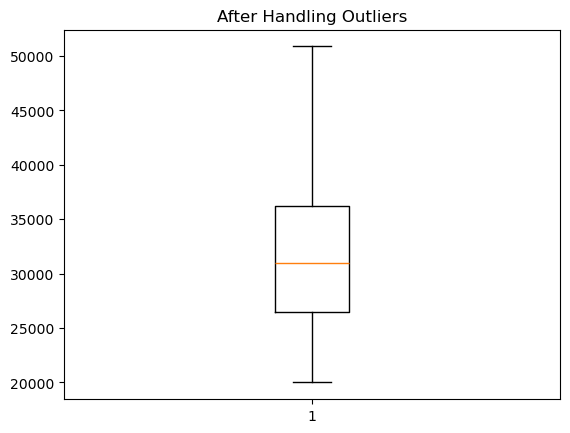

In [17]:
# Compare After Handling
plt.boxplot(df_capped["Salary"])
plt.title("After Handling Outliers")
plt.show()